## **Phase 1: Environment & Data Preparation**

### **Environment Setup**

#### Install and import required packages

In [2]:
import subprocess
import sys


def pip_install(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", *args])


# Install into the active Jupyter kernel, not whatever plain `pip` resolves to.
pip_install("-q", "kaggle")
pip_install("-q", "-U", "google-generativeai")
pip_install("-q", "nmslib", "faiss-cpu")
pip_install("-qU", "sentence-transformers==2.7.0")
pip_install("-qU", "datasets==2.19.1")

if sys.version_info >= (3, 13):
    pip_install("-qU", "pyarrow>=19")
else:
    pip_install("-qU", "pyarrow==15.0.2")

pip_install("-q", "pyserini==0.21.0")
pip_install("python-dotenv")
pip_install("-q", "matplotlib")
pip_install("-q", "seaborn")

In [3]:
import os

# Set JAVA_HOME
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-21.0.10.7-hotspot"

# Add Java to PATH
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

In [4]:
import re
import json
import time
import torch
import zipfile
import subprocess
import numpy as np
import pandas as pd
import torch.nn.functional as F
import google.generativeai as genai
from tqdm import tqdm
from dotenv import load_dotenv
from google.api_core import exceptions
from torch.utils.data import DataLoader
from pyserini.search.lucene import LuceneSearcher
from sentence_transformers import CrossEncoder, InputExample

d:\Dev Repos\master_thesis\.conda\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
d:\Dev Repos\master_thesis\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\wilss\AppData\Local\Temp\ipykernel_19540\988328593.py:10: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

ht

In [5]:
# load environment variables
load_dotenv()

False

#### Set up file paths and folder structure

In [6]:
# Base project directory
base_dir = f"D:\josna_thesis\master_thesis"

# arxiv dataset
arxiv_dir = f"{base_dir}/data/arxiv"
arxiv_file = f"{arxiv_dir}/arxiv-metadata-oai-snapshot.json"

# processed data
processed_dir = f"{base_dir}/data/processed"
arxiv_chunks = f"{processed_dir}/arxiv_chunks.parquet"
processed_aar_training = f"{processed_dir}/aar_training_data.csv"
processed_pyserini_ingest_dir = f"{processed_dir}/pyserini_ingest"
processed_bm25_index = f"{processed_dir}/bm25_index"
processed_final_evaluation_report = f"{processed_dir}/final_evaluation_report.csv"
processed_aar_dataset = f"{processed_dir}/aar_dataset.jsonl"

# Models
aar_trained_model = f"{base_dir}/models/aar_trained_model"

# Other files
evaluation_queries = f"{base_dir}/data/evaluation_queries.json"

# results
results_dir = f"{base_dir}/results"

In [7]:
# Set up subfolders
folders = [
    'data/arxiv',
    'data/processed',
    'data/processed/bm25_index',
    'data/processed/pyserini_ingest',
    'models/aar_trained_model',
    'results'
]

# Verifying and Creating directories as needed
for folder in folders:
    path = os.path.join(base_dir, folder)
    os.makedirs(path, exist_ok=True)
    print(f"Verified: {path}")

Verified: D:\josna_thesis\master_thesis\data/arxiv
Verified: D:\josna_thesis\master_thesis\data/processed
Verified: D:\josna_thesis\master_thesis\data/processed/bm25_index
Verified: D:\josna_thesis\master_thesis\data/processed/pyserini_ingest
Verified: D:\josna_thesis\master_thesis\models/aar_trained_model
Verified: D:\josna_thesis\master_thesis\results


### **Dataset Acquisition & Preprocessing**

#### Download ArXiv Dataset

In [ ]:
# Retrieve Kaggle credentials
os.environ['KAGGLE_USERNAME'] = os.getenv("KAGGLE_USERNAME")
os.environ['KAGGLE_KEY'] = os.getenv("KAGGLE_KEY")

# Change directory to arxiv
os.chdir(arxiv_dir)

# Download dataset
subprocess.run(["kaggle", "datasets", "download", "-d", "Cornell-University/arxiv"])

# Unzip dataset
with zipfile.ZipFile("arxiv.zip", 'r') as zip_ref:
    zip_ref.extractall(arxiv_dir)

# Remove zip file
os.remove("arxiv.zip")

print("Download and extraction complete.")

#### Clean the data and implement sliding window chunking

In [8]:
# function to clean data
def clean_latex_and_brackets(text):
   """
   Cleans LaTeX commands, math blocks, and citation brackets.
   """
   if not isinstance(text, str):
       return ""

   # Remove LaTeX math blocks: $$...$$ and $...$
   text = re.sub(r'\$\$.*?\$\$', '', text, flags=re.DOTALL)
   text = re.sub(r'\$.*?\$', '', text)

   # Remove common LaTeX commands and the curly braces (e.g., \section, \textbf, \cite{...})
   text = re.sub(r'\\[a-zA-Z]+\{.*?\}', '', text)

   # Remove standalone backslashes and remaining LaTeX commands (e.g., \item, \noindent)
   text = re.sub(r'\\[a-zA-Z]+', '', text)

   # Remove citation/reference brackets like [1], [12, 15], or [Smith et al., 2023]
   text = re.sub(r'\[[\d, \s\-a-zA-Z\.]+\]', '', text)

   # Clean up extra whitespace/newlines left behind
   text = re.sub(r'\s+', ' ', text).strip()

   return text

In [9]:
# Function to chunk text using simple sliding window chunker
def chunk_text(text, chunk_size=512, overlap=50):
   cleaned_text = clean_latex_and_brackets(text)
   words = cleaned_text.split()
   chunks = []
   for i in range(0, len(words), chunk_size - overlap):
       chunk = " ".join(words[i:i + chunk_size])
       chunks.append(chunk)
   return chunks

In [ ]:
# The ArXiv dataset is a massive JSON file. The below code will extract and chunk the text.
processed_chunks = []

with open(arxiv_file, 'r') as f:
   for i, line in enumerate(f):
      #  if i >= 2: break # Process subset for testing
       data = json.loads(line)
       # Focus on 'abstract' as the primary text source for RAG
       full_text = f"Title: {data['title']}\nAbstract: {data['abstract']}"
       chunks = chunk_text(full_text)
       for c in chunks:
           processed_chunks.append({"id": data['id'], "chunk": c})

In [ ]:

# Save processed chunks as a Parquet for Phase 2 reranking
chunks_df = pd.DataFrame(processed_chunks)
chunks_df.to_parquet(arxiv_chunks)
print(f"Saved {len(chunks_df)} chunks for RAG pipeline.")

### **Indexing (Stage 1 Retriever)**

#### Convert Data to Pyserini Format

In [ ]:
# Load your cleaned chunks
df = pd.read_parquet(arxiv_chunks)

# Write chunks to JSONL format
with open(os.path.join(processed_pyserini_ingest_dir, 'docs.jsonl'), 'w') as f:
    for _, row in df.iterrows():
        # Pyserini requires 'id' and 'contents' fields
        pyserini_doc = {
            "id": str(row['id']),
            "contents": row['chunk']
        }
        f.write(json.dumps(pyserini_doc) + '\n')

print(f"Converted {len(df)} chunks to Pyserini-compatible JSONL.")

Converted 2982135 chunks to Pyserini-compatible JSONL.


#### Build the BM25 Index

In [12]:
# Run the Pyserini indexer
!python -m pyserini.index.lucene \
  --collection JsonCollection \
  --input {processed_pyserini_ingest_dir} \
  --index {processed_bm25_index} \
  --generator DefaultLuceneDocumentGenerator \
  --threads 8 \
  --storePositions --storeDocvectors --storeRaw

print(f"BM25 Index successfully built at: {processed_bm25_index}")

2026-03-17 14:37:37,233 INFO  [main] index.IndexCollection (IndexCollection.java:380) - Setting log level to INFO
2026-03-17 14:37:37,237 INFO  [main] index.IndexCollection (IndexCollection.java:383) - Starting indexer...
2026-03-17 14:37:37,237 INFO  [main] index.IndexCollection (IndexCollection.java:384) - ============ Loading Parameters ============
2026-03-17 14:37:37,237 INFO  [main] index.IndexCollection (IndexCollection.java:385) - DocumentCollection path: D:\dev_repo/data/processed/pyserini_ingest
2026-03-17 14:37:37,238 INFO  [main] index.IndexCollection (IndexCollection.java:386) - CollectionClass: JsonCollection
2026-03-17 14:37:37,238 INFO  [main] index.IndexCollection (IndexCollection.java:387) - Generator: DefaultLuceneDocumentGenerator
2026-03-17 14:37:37,238 INFO  [main] index.IndexCollection (IndexCollection.java:388) - Threads: 8
2026-03-17 14:37:37,238 INFO  [main] index.IndexCollection (IndexCollection.java:389) - Language: en
2026-03-17 14:37:37,238 INFO  [main] in

## **Common Functions**

In [19]:
# Initialize BM25 Searcher
searcher = LuceneSearcher(processed_bm25_index)

# Initial candidate retrieval using BM25. This is the common first stage used by both the baseline and proposed systems.
def Initial_BM25_Candidate_Retrieval(query, k=50):
    # Retrieval (BM25)
    hits = searcher.search(query, k=k)

    # Extract passages for reranking
    passages = [json.loads(searcher.doc(h.docid).raw())['contents'] for h in hits]

    return passages

# Build (query, passage) pairs for cross-encoder style reranking.
def Build_Model_Inputs(query, passages):
    return [[query, passage] for passage in passages]

# Standard relevance-based reranking using an off-the-shelf cross-encoder.
def Baseline_Relevance_Reranking(query, passages, top_n=5):
    model_inputs = Build_Model_Inputs(query, passages)
    scores = baseline_reranker.predict(model_inputs)

    # Sort passages by descending score and return the top_n passages.
    ranked_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    return [passages[i] for i in ranked_indices[:top_n]]

# AAR Reranking
def Proposed_Attribution_Aware_Reranking(query, passages, top_n=5):
    model_inputs = Build_Model_Inputs(query, passages)
    scores = aar_reranker.predict(model_inputs, batch_size=8)

    # Prioritize class 1 (Attributable) by taking the softmax score for index 1 
    probs = F.softmax(torch.tensor(scores), dim=1)
    attributable_scores = probs[:,1].tolist()

    ranked_indices = sorted(range(len(attributable_scores)),
                            key=lambda i: attributable_scores[i], reverse=True)

    top_verified_passages = [passages[i] for i in ranked_indices[:top_n]]    
    return top_verified_passages

def Generate_Prompt(top_passages):
    context_str = ""
    for i, p in enumerate(top_passages):
        context_str += f"Source [Doc_{i}]: {p}\n\n"

    prompt = f"""Answer the query using only the sources provided.
You MUST cite the Source ID (e.g. [Doc_0]) immediately after the sentence it supports.
Use only the provided sources when making cited factual claims.
If the sources do not fully support a claim, state the uncertainty clearly.

Sources:
{context_str}
Query: {query}
"""
    return prompt

## **Phase 2: Baseline Implementation**

#### Setting up the vertex api to access google cloud platform

In [ ]:
# Install Vertex AI SDK
!pip install -q google-cloud-aiplatform

import os
import time
import random
import vertexai
from google.api_core.exceptions import ResourceExhausted, ServiceUnavailable, DeadlineExceeded
from vertexai.generative_models import GenerativeModel

PROJECT_ID = os.getenv("PROJECT_ID", "project-eb7a852b-1394-44fe-b5f")
VERTEX_LOCATION = os.getenv("VERTEX_LOCATION", "global")

vertexai.init(project=PROJECT_ID, location=VERTEX_LOCATION)

# Load Gemini model
llm_generator = GenerativeModel("gemini-2.5-flash")

def generate_content_with_retry(prompt, model=None, retries=8,
                                initial_delay=5.0, max_delay=60.0,
                                temperature=None, sleep_after_success=0.5):
    model = model or llm_generator
    delay = initial_delay
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            if temperature is None:
                response = model.generate_content(prompt)
            else:
                from vertexai.generative_models import GenerationConfig
                response = model.generate_content(
                    prompt,
                    generation_config=GenerationConfig(temperature=temperature)
                )
            time.sleep(sleep_after_success)
            return response
        except (ResourceExhausted, ServiceUnavailable, DeadlineExceeded) as e:
            last_error = e
            if attempt == retries:
                raise
            wait_time = min(max_delay, delay + random.uniform(0, delay * 0.25))
            print(f"Vertex AI transient error on attempt {attempt}/{retries}: {e}. Retrying in {wait_time:.1f}s...")
            time.sleep(wait_time)
            delay *= 2

    raise last_error


Unable to create process using 'd:\Dev Repos\master_thesis\.conda\python.exe "d:\Dev Repos\master_thesis\.conda\Scripts\pip-script.py" install -q google-cloud-aiplatform'
d:\Dev Repos\master_thesis\.conda\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.aiplatform_v1beta1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1beta1 past that date.
  warnings.warn(message, FutureWarning)
d:\Dev Repos\master_thesis\.conda\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.aiplatform_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11

### **Construct the Pipeline**

#### **Implement Citation Audit Evaluator to Audit the Baseline**

In [11]:
class CitationAuditEvaluator:
    """
    Standalone evaluator for cited RAG outputs.
    This audits the answer but does not correct, rewrite, or retrieve new evidence.
    """

    def __init__(self, aar_model, margin_threshold=0.035):
        self.evaluator = aar_model
        self.margin_threshold = margin_threshold

    def extract_citations(self, response_text):
        pattern = r"([^.!?]+?)\s*\[([^\]]+)\]"
        matches = re.findall(pattern, response_text)

        extracted = []
        for claim, citation_text in matches:
            claim = claim.strip()
            doc_ids = [c.strip() for c in citation_text.split(",") if c.strip()]
            if claim:
                extracted.append({
                    "claim": claim,
                    "doc_ids": doc_ids
                })
        return extracted

    def verify_claim_against_source(self, claim, source_text):
        prediction = self.evaluator.predict([[claim, source_text]], apply_softmax=True)[0]

        contradict_prob = float(prediction[0])
        attributable_prob = float(prediction[1])
        extrapolatory_prob = float(prediction[2])

        predicted_class = int(np.argmax(prediction))
        sorted_probs = sorted([contradict_prob, attributable_prob, extrapolatory_prob], reverse=True)
        margin = float(sorted_probs[0] - sorted_probs[1])

        status = "PASS" if predicted_class == 1 and margin >= self.margin_threshold else "FAIL"

        return {
            "status": status,
            "confidence": attributable_prob,
            "predicted_class": predicted_class,
            "contradict_prob": contradict_prob,
            "attributable_prob": attributable_prob,
            "extrapolatory_prob": extrapolatory_prob,
            "margin": margin
        }

    def audit_response(self, response_text, retrieved_passages):
        extracted_claims = self.extract_citations(response_text)
        verifications = []

        for item in extracted_claims:
            claim = item["claim"]

            for doc_id_str in item["doc_ids"]:
                doc_match = re.search(r"\d+", doc_id_str)
                if not doc_match:
                    verifications.append({
                        "claim": claim,
                        "doc_id": doc_id_str,
                        "source": None,
                        "status": "FAIL",
                        "confidence": 0.0,
                        "error": "Could not parse document id"
                    })
                    continue

                doc_idx = int(doc_match.group())
                if doc_idx < 0 or doc_idx >= len(retrieved_passages):
                    verifications.append({
                        "claim": claim,
                        "doc_id": doc_id_str,
                        "source": None,
                        "status": "FAIL",
                        "confidence": 0.0,
                        "error": "Document index out of range"
                    })
                    continue

                source_text = retrieved_passages[doc_idx]
                audit = self.verify_claim_against_source(claim, source_text)

                verifications.append({
                    "claim": claim,
                    "doc_id": doc_id_str,
                    "source": source_text,
                    **audit
                })

        return {
            "response_text": response_text,
            "num_extracted_claims": len(extracted_claims),
            "verifications": verifications
        }

    def compute_metrics(self, audit_result):
        verifications = audit_result.get("verifications", [])
        
        if len(verifications) == 0:
            print("No verifications found")
            return {
                "precision": 0.0,
                "recall": 0.0,
                "ags": 0.0,
                "num_verified_claims": 0,
                "num_passed": 0,
                "num_failed": 0
            }

        passed = [v for v in verifications if v["status"] == "PASS"]
        failed = [v for v in verifications if v["status"] == "FAIL"]
        
        precision = len(passed) / len(verifications)
        
        num_extracted_claims = max(audit_result.get("num_extracted_claims", 0), 1)
        recall = len(passed) / num_extracted_claims
        
        grounding_scores = []
        for v in passed:
            source = v.get("source", "")
            wc = len(source.split()) if source else 0
            if wc > 0:
                grounding_scores.append(100 / wc)

        ags = float(np.mean(grounding_scores)) if grounding_scores else 0.0
        
        return {
            "precision": float(precision),
            "recall": float(recall),
            "ags": float(ags),
            "num_verified_claims": int(len(verifications)),
            "num_passed": int(len(passed)),
            "num_failed": int(len(failed))
        }

#### ** implement baseline**

In [12]:
# Initialize Baseline Relevance Reranker (Standard Cross-Encoder)
# Using ms-marco-MiniLM as it is the standard for semantic relevance
baseline_reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

# Function to implement the baseline pipeline
def baseline_rag_pipeline(query, k=50, top_n=5, require_citations=False):
    # BM25 candidate retrieval
    candidate_passages = Initial_BM25_Candidate_Retrieval(query, k=k)
    top_passages = Baseline_Relevance_Reranking(query, candidate_passages, top_n=top_n)

    prompt = Generate_Prompt(top_passages)    

    response = generate_content_with_retry_and_cache(prompt, model=llm_generator)
    response_text = response.text if hasattr(response, "text") else str(response)

    return {
        "query": query,
        "retrieved_passages": top_passages,
        "generated_answer": response_text
    }

# Function to Audit the baseline pipeline
def audit_baseline_rag_pipeline(query, k=50, top_n=5):
    baseline_out = baseline_rag_pipeline(query, k=k, top_n=top_n, require_citations=True)
    audit_result = citation_auditor.audit_response(
        baseline_out["generated_answer"],
        baseline_out["retrieved_passages"]
    )
    
    metrics = citation_auditor.compute_metrics(audit_result)
    
    return {
        "query": query,
        "generated_answer": baseline_out["generated_answer"],
        "retrieved_passages": baseline_out["retrieved_passages"],
        "audit": audit_result,
        "verifications": audit_result["verifications"],
        **metrics
    }

### **Synthetic Data Generation**

#### **JSON Functions required to generate synthetic data**

In [13]:
# Simple function to fix invalid JSON generated from the generator
def fix_invalid_escapes(text):
    # Replace single backslashes not part of valid escapes
    return re.sub(r'\\(?!["\\/bfnrtu])', r'\\\\', text)

# Function to attempt to parse JSON with fallback fixes
def safe_json_loads(text):
    """
    Attempt to parse JSON with fallback fixes.
    """
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        try:
            fixed = fix_invalid_escapes(text)
            return json.loads(fixed)
        except Exception:
            return None

#### **AAR Triplets generator**

In [ ]:
# Define variables for the generation of train data
buffer = []
target_passages = 20000
processed = 0
batch_size = 10

In [ ]:
def generate_aar_triplets_batch(passages, retries=5):
    cleaned_passages = [
        p for p in (clean_latex_and_brackets(p) for p in passages)
        if p and len(p) > 50
    ]

    if not cleaned_passages:
        print("Error: No passages returned after cleaning!")
        return []

    context = "\n\n".join(
        [f"passage_id {i+1}: {p}" for i, p in enumerate(cleaned_passages)]
    )

    prompt = f"""
Below are several context passages.

{context}

For EACH passage generate JSON object with exactly three claims:
1. "attributable": A claim fully and directly supported by the text.
2. "extrapolatory": A claim topically related to the text but NOT supported by it.
3. "contradictory": A claim that directly contradicts information in the text.

Return ONLY valid JSON list:
[
    {{
        "passage_id": "...",
        "passage": "...",
        "attributable": "...",
        "extrapolatory": "...",
        "contradictory": "..."
    }}
]
"""

    for attempt in range(retries):
        try:
            response = generate_content_with_retry(prompt)
            text = response.text.replace("```json", "").replace("```", "").strip()

            data = safe_json_loads(text)

            if data is None:
                raise ValueError("Failed to parse JSON after fixes")

            valid_data = []
            for i, d in enumerate(data):
                try:
                    d["passage"] = cleaned_passages[i]
                    valid_data.append(d)
                except Exception as e:
                    print(f"Skipping malformed item {i}: {e}")

            return valid_data

        except exceptions.ResourceExhausted:
            wait = (2 ** attempt) + 5
            print(f"Rate limit hit. Waiting {wait}s")
            time.sleep(wait)

        except Exception as e:
            print("Error:", e)

    return []

In [15]:
# retrieve chunked data
reader = pd.read_parquet(arxiv_chunks, columns=["chunk"])

# process and store the AAR triplet dataset
with open(processed_aar_dataset, "a") as f:
    for passage in tqdm(reader["chunk"], total=target_passages):
        cleaned = clean_latex_and_brackets(passage)

        if not cleaned or len(cleaned) < 50:
          print(f"Error: Passage cleaned came empty. Original passage: {passage} \n cleaned: {cleaned}")
          continue

        buffer.append(cleaned)
        processed += 1

        if len(buffer) == batch_size:
            triplets = generate_aar_triplets_batch(buffer)
            for t in triplets:
                f.write(json.dumps(t) + "\n")
            buffer = []

        if processed >= target_passages:
            break

    # process leftover buffer
    if buffer:
        triplets = generate_aar_triplets_batch(buffer)
        for t in triplets:
            f.write(json.dumps(t) + "\n")
print("Triplet generation complete.")

  1%|          | 200/20000 [09:14<15:45:00,  2.86s/it]

Error: Failed to parse JSON after fixes
Error: Failed to parse JSON after fixes
Error: Failed to parse JSON after fixes
Error: Failed to parse JSON after fixes


  1%|          | 210/20000 [11:29<33:20:08,  6.06s/it]

Error: Failed to parse JSON after fixes


  1%|          | 230/20000 [12:23<23:56:10,  4.36s/it]

...

Error: Failed to parse JSON after fixes
Error: Failed to parse JSON after fixes
Error: Failed to parse JSON after fixes


 97%|█████████▋| 19350/20000 [13:27:28<23:48,  2.20s/it]  

Error: Failed to parse JSON after fixes


100%|█████████▉| 19999/20000 [13:53:19<00:02,  2.50s/it]

Triplet generation complete.


#### Save the processed dataset for  attribution aware training

In [ ]:
# SAFETY CHECK: Only load if the JSONL file exists and is not empty
if os.path.exists(processed_aar_dataset) and os.path.getsize(processed_aar_dataset) > 0:
    try:
        # Load JSONL
        final_df = pd.read_json(processed_aar_dataset, lines=True)

        if final_df.empty:
            raise ValueError("Loaded DataFrame is empty")

        # Save CSV
        final_df.to_csv(processed_aar_training, index=False)

        # VERIFY CSV WRITE
        if os.path.exists(processed_aar_training):
            size = os.path.getsize(processed_aar_training)

            if size > 0:
                try:
                    # Try reading it back to ensure it's not corrupted
                    test_df = pd.read_csv(processed_aar_training)

                    if not test_df.empty:
                        print(f"Successfully saved {len(final_df)} rows to {processed_aar_training}")

                        # DELETE SOURCE FILE ONLY AFTER SUCCESS
                        os.remove(processed_aar_dataset)
                        print(f"Deleted source file: {processed_aar_dataset}")

                    else:
                        print("ERROR: CSV read succeeded but file is empty. Not deleting JSONL.")

                except Exception as e:
                    print(f"ERROR: CSV verification failed: {e}. Not deleting JSONL.")

            else:
                print("ERROR: CSV file is empty. Not deleting JSONL.")

        else:
            print("ERROR: CSV file was not created. Not deleting JSONL.")

    except Exception as e:
        print(f"CRITICAL ERROR during processing: {e}. JSONL NOT deleted.")

else:
    print("CRITICAL ERROR: No data file found or file is empty. Check your generator.")

Successfully saved 19958 rows to D:\dev_repo/data/processed/aar_training_data.csv
Deleted source file: D:\dev_repo/data/processed/aar_dataset.jsonl


#### Normalize and clean the dataset before training

In [14]:
# function to normalize the data
def normalize_triplet(row):

    if isinstance(row.get("claims"), list):

        attr = None
        extra = None
        contra = None

        for c in row["claims"]:
            t = c.get("type")
            txt = c.get("claim") or c.get("text")

            if t == "attributable":
                attr = txt
            elif t == "extrapolatory":
                extra = txt
            elif t == "contradictory":
                contra = txt

        return pd.Series({
            "attributable": attr,
            "extrapolatory": extra,
            "contradictory": contra
        })

    else:
        return pd.Series({
            "attributable": row.get("attributable"),
            "extrapolatory": row.get("extrapolatory"),
            "contradictory": row.get("contradictory")
        })

In [ ]:
# Fetch the data
final_df = pd.read_csv(processed_aar_training)

In [18]:
# Normalize the data
normalized = final_df.apply(normalize_triplet, axis=1)

final_df["attributable"] = normalized["attributable"]
final_df["extrapolatory"] = normalized["extrapolatory"]
final_df["contradictory"] = normalized["contradictory"]

In [19]:
# Drop rows where any of the key columns are missing
df = pd.DataFrame(final_df.dropna(subset=["attributable", "extrapolatory", "contradictory"]))

# Convert relevant columns to string
cols_to_string = ["passage", "attributable", "extrapolatory", "contradictory"]
df[cols_to_string] = df[cols_to_string].astype(str)

# Drop columns we don't need
cols_to_drop = ["passage_id", "passage_number", "claims"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

#### Prepare sample dataset for model training

In [20]:
# Labels: 0 = Contradictory, 1 = Attributable, 2 = Extrapolatory
train_examples = []

for _, row in df.iterrows():
    train_examples.append(
        InputExample(texts=[row['attributable'], row['passage']], label=float(1))
    )
    train_examples.append(
        InputExample(texts=[row['extrapolatory'], row['passage']], label=float(2))
    )
    train_examples.append(
        InputExample(texts=[row['contradictory'], row['passage']], label=float(0))
    )

## **Phase 3: Model Training (NLI Objective)**

#### Check system configuration for better performance

In [21]:
# check if device has gpu
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

is_gpu_available = True if device == "cuda" else False

# Empty cache for GPU use
if is_gpu_available is True:
    torch.cuda.empty_cache()

Using device: cpu


### **Train the model**

In [23]:
# Initialize Architecture (DeBERTa-v3-base cam as highly recommended for NLI)
model = CrossEncoder('microsoft/deberta-v3-base', num_labels=3, max_length=128, device=device)

# Fine-tune with Cross-Entropy Loss
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16, num_workers=4, pin_memory=is_gpu_available)

epochs = 2
total_steps = len(train_dataloader) * epochs

# with tqdm(total=total_steps, desc="Training Progress") as pbar:

#     def progress_callback(current_step, total_steps):
#         pbar.n = current_step
#         pbar.refresh()

# train the model
model.fit(
    train_dataloader=train_dataloader,
    epochs=epochs,
    warmup_steps=100,
    show_progress_bar=True,  # disable internal progress bar as there is explicit progress bar added
    use_amp=is_gpu_available
)

# save trained model
model.save(aar_trained_model)

print("Phase 3 Complete: AAR Model trained and saved to Drive.")

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
d:\Dev Repos\master_thesis\.conda\lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Epoch: 100%|██████████| 2/2 [9:32:15<00:00, 17167.94s/it]  


Phase 3 Complete: AAR Model trained and saved to Drive.


In [16]:
# # Load AAR
aar_reranker = CrossEncoder(aar_trained_model, num_labels=3, max_length=256)

The tokenizer you are loading from 'D:\josna_thesis\master_thesis/models/aar_trained_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


## **Phase 4: Developing the CVL (Corrective Verification Loop)**

### **Implementation of the CVL Logic**

In [20]:
class CorrectiveVerificationLoop:
    def __init__(self, aar_model, searcher, threshold=0.35):
        self.evaluator = aar_model # trained AAR Cross-Encoder
        self.searcher = searcher    # Pyserini LuceneSearcher
        self.threshold = threshold  # Confidence required to "Pass"

    def extract_citations(self, text):
        # Regex to find sentences followed by [bracketed_ids]
        pattern = r"([^.!?]+)\s*\[([^\]]+)\]"
        matches = re.findall(pattern, text)
        return matches

    def verify_and_correct(self, generated_text, source_passages):
        claims = self.extract_citations(generated_text)
        verified_results = []
        needs_correction = False

        for claim, doc_id_str in claims:
            # Extract the numeric index from IDs like [Doc_0]
            try:
                # This fixes the lookup error by mapping Doc_N to source_passages[N]
                doc_idx = int(re.search(r"\d+", doc_id_str).group())
                source_text = source_passages[doc_idx]
            except (ValueError, IndexError, AttributeError):
                print(f"Warning: Source ID {doc_id_str} could not be mapped to retrieved passages.")
                continue

            # Score with AAR (0: Contradict, 1: Attributable, 2: Extrapolatory)
            prediction = self.evaluator.predict([[claim, source_text]], apply_softmax=True)[0]
            confidence_score = prediction[1]

            if confidence_score >= self.threshold:
                verified_results.append({"claim": claim, "source": source_text, "status": "PASS" if confidence_score >= self.threshold else "FAIL", "confidence": confidence_score})
            else:
                print(f"CVL Alert: Mismatch found for claim: '{claim[:50]}...'")
                verified_results.append({"claim": claim, "source": source_text, "status": "PASS" if confidence_score >= self.threshold else "FAIL", "confidence": confidence_score})
                needs_correction = True

        return verified_results, needs_correction


# Initialize the CVL with the trained model
cvl = CorrectiveVerificationLoop(aar_model=aar_reranker, searcher=searcher)

## **Integration: The Full 4-Stage Workflow**

In [21]:
def proposed_rag_pipeline(query):
    # BM25 candidate retrieval
    candidate_passages = Initial_BM25_Candidate_Retrieval(query, k=k)
    top_verified_passages = Proposed_Attribution_Aware_Reranking(query, candidate_passages, top_n=top_n)

    # top_verified_passages = attribution_aware_rag_pipeline(query)

    prompt = Generate_Prompt(top_passages)    

    response = generate_content_with_retry_and_cache(prompt, model=llm_generator)

    verifications, correction_needed = cvl.verify_and_correct(response, top_verified_passages)    

    if correction_needed:
        # Fallback Logic: Qualify the response if verification fails
        final_output = response + "\n\n[CVL NOTE: Some citations in this response could not be fully verified against the source text.]"
    else:
        final_output = response

    return final_output, verifications

## **Phase 5: Evaluation & Analysis**

### **Metric Implementation**

In [22]:
class RAGEvaluator:
    def __init__(self):
        pass

    def calculate_attr_scores(self, verifications):
        if not verifications:
            return 0.0, 0.0

        tp = sum(1 for v in verifications if v['status'] == 'PASS')
        fp = sum(1 for v in verifications if v['status'] == 'FAIL')

        # Citation Precision: Accuracy of the citations provided
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

        # Citation Recall: Proportion of necessary info correctly cited
        total_claims = len(verifications)
        recall = tp / total_claims if total_claims > 0 else 0.0

        return float(precision), float(recall)

    # Attribution Granularity Score (AGS)
    def calculate_ags(self, retrieved_passages):
        if not retrieved_passages:
            return 0.0

        granularity_scores = []
        for p in retrieved_passages:
            word_count = len(p.split())
            granularity_scores.append(100 / word_count if word_count > 0 else 0)

        return float(np.mean(granularity_scores))

# Initialize Evaluator
evaluator = RAGEvaluator()

# External auditor for baseline-without-CVL measurement
citation_auditor = CitationAuditEvaluator(aar_reranker, margin_threshold=0.035)


In [23]:
def make_json_safe(obj):
    import numpy as np

    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    return obj

### **Experimental Results and Performance Analysis**

In [24]:
import os
import json
import hashlib
import time
import random

CACHE_DIR = os.path.join(results_dir, "vertex_cache")
os.makedirs(CACHE_DIR, exist_ok=True)

def prompt_cache_key(prompt, model_name="gemini-2.5-flash", temperature=None):
    payload = json.dumps({
        "model": model_name,
        "temperature": temperature,
        "prompt": prompt
    }, sort_keys=True, ensure_ascii=False)
    return hashlib.md5(payload.encode("utf-8")).hexdigest()

def generate_content_with_retry_and_cache(
    prompt,
    model,
    model_name="gemini-2.5-flash",
    retries=8,
    initial_delay=3.0,
    max_delay=90.0,
    temperature=None,
    sleep_after_success=1.5,
    use_cache=True
):
    cache_path = os.path.join(
        CACHE_DIR,
        f"{prompt_cache_key(prompt, model_name=model_name, temperature=temperature)}.json"
    )

    if use_cache and os.path.exists(cache_path):
        with open(cache_path, "r", encoding="utf-8") as f:
            cached = json.load(f)

        class CachedResponse:
            def __init__(self, text):
                self.text = text

        return CachedResponse(cached["text"])

    delay = initial_delay
    last_error = None

    for attempt in range(retries):
        try:
            if temperature is None:
                response = model.generate_content(prompt)
            else:
                from vertexai.generative_models import GenerationConfig
                response = model.generate_content(
                    prompt,
                    generation_config=GenerationConfig(temperature=temperature)
                )

            response_text = response.text if hasattr(response, "text") else str(response)

            if use_cache:
                with open(cache_path, "w", encoding="utf-8") as f:
                    json.dump({"text": response_text}, f, ensure_ascii=False, indent=2)

            time.sleep(sleep_after_success + random.uniform(0.2, 0.8))
            return response

        except Exception as e:
            last_error = e
            msg = str(e).lower()

            retryable = (
                "429" in msg or
                "resource exhausted" in msg or
                "too many requests" in msg or
                "quota" in msg
            )

            if not retryable:
                raise

            if attempt == retries - 1:
                raise

            sleep_time = min(delay, max_delay) + random.uniform(0.5, 2.0)
            print(f"[Retry {attempt+1}/{retries}] Vertex busy. Sleeping {sleep_time:.1f}s")
            time.sleep(sleep_time)
            delay *= 2

    raise last_error

In [ ]:
# fetch test queries for evaluation
with open(evaluation_queries, "r") as f:
    data = json.load(f)

test_queries = data["queries"]

comparison_data = []
baseline_no_cvl_log = []
baseline_with_cvl_log = []
proposed_audit_log = []

print("Running final three-way comparison...")
for query in test_queries:
    print(f"\nEvaluating query: {query}")

    # 1. Baseline without CVL
    baseline_no_cvl_out = audit_baseline_rag_pipeline(query)
    b0_prec = baseline_no_cvl_out['precision']
    b0_rec = baseline_no_cvl_out['recall']
    b0_ags = baseline_no_cvl_out['ags']

    # 3. Proposed Framework (AAR + CVL)
    final_answer, audit_log = proposed_rag_pipeline(query)
    p_prec, p_rec = evaluator.calculate_attr_scores(audit_log)
    passed_passages = [v['source'] for v in audit_log if v['status'] == 'PASS']
    p_ags = evaluator.calculate_ags(passed_passages) if passed_passages else 0.0

    baseline_no_cvl_log.append({
        "Query": query,
        "Baseline_NoCVL_Answer": baseline_no_cvl_out['generated_answer'],
        "Baseline_NoCVL_Verifications": baseline_no_cvl_out['verifications'],
        "Baseline_NoCVL_Num_Verified_Claims": baseline_no_cvl_out['num_verified_claims'],
        "Baseline_NoCVL_Num_Pass": baseline_no_cvl_out['num_passed'],
        "Baseline_NoCVL_Num_Fail": baseline_no_cvl_out['num_failed'],
        "Baseline_NoCVL_Prec": b0_prec,
        "Baseline_NoCVL_Rec": b0_rec,
        "Baseline_NoCVL_AGS": b0_ags
    })

    proposed_audit_log.append({
        "Query": query,
        "Proposed_Answer": final_answer,
        "Proposed_Verifications": audit_log,
        "Proposed_Num_Verified_Claims": len(audit_log),
        "Proposed_Num_Pass": sum(1 for v in audit_log if v['status'] == 'PASS'),
        "Proposed_Num_Fail": sum(1 for v in audit_log if v['status'] == 'FAIL'),
        "Proposed_Prec": p_prec,
        "Proposed_Rec": p_rec,
        "Proposed_AGS": p_ags
    })

    comparison_data.append({
        "Query": query,

        "Baseline_NoCVL_Prec": b0_prec,
        "Baseline_NoCVL_Rec": b0_rec,
        "Baseline_NoCVL_AGS": b0_ags,
        "Baseline_NoCVL_Num_Verified_Claims": baseline_no_cvl_out['num_verified_claims'],

        "Proposed_Prec": p_prec,
        "Proposed_Rec": p_rec,
        "Proposed_AGS": p_ags,
        "Proposed_Num_Verified_Claims": len(audit_log),

        "Delta_Prec_Proposed_vs_BaselineNoCVL": float(p_prec - b0_prec),
        "Delta_Rec_Proposed_vs_BaselineNoCVL": float(p_rec - b0_rec),
        "Delta_AGS_Proposed_vs_BaselineNoCVL": float(p_ags - b0_ags)
    })

results_df = pd.DataFrame(comparison_data)
print("=== FINAL THREE-WAY THESIS COMPARISON TABLE ===")
display(results_df)

# Save detailed per-query audit logs for transparency and reproducibility
with open(os.path.join(results_dir, "baseline_no_cvl_audit.json"), "w", encoding="utf-8") as f:
    json.dump(make_json_safe(baseline_no_cvl_log), f, indent=2, ensure_ascii=False)

with open(os.path.join(results_dir, "proposed_query_audit.json"), "w", encoding="utf-8") as f:
    json.dump(make_json_safe(proposed_audit_log), f, indent=2, ensure_ascii=False)

results_df.to_csv(os.path.join(results_dir, "final_comparison_report_three_way.csv"), index=False)

print("Saved:")
print("- baseline_no_cvl_audit.json")
print("- proposed_query_audit.json")
print("- final_comparison_report_three_way.csv")


Running final three-way comparison...

Evaluating query: What is the main contribution of the paper on sparsity-certifying graph decompositions?
debug 1
debug 2
No verifications found

Evaluating query: How does the colored pebble game help in certifying sparsity of graphs?
debug: predicted_class: 1, margin: 0.03779953718185425, margin_threshold: 0.035
debug: predicted_class: 1, margin: 0.03675258159637451, margin_threshold: 0.035
debug: predicted_class: 1, margin: 0.03484806418418884, margin_threshold: 0.035
debug: predicted_class: 1, margin: 0.035851627588272095, margin_threshold: 0.035
debug 1
debug 2
debug 3: Pass: [{'claim': 'The -pebble game with colors helps obtain a characterization of the family of -sparse graphs', 'doc_id': 'Doc_0', 'source': 'Title: Sparsity-certifying Graph Decompositions. Abstract: We describe a new algorithm, the -pebble game with colors, and use it obtain a characterization of the family of -sparse graphs and algorithmic solutions to a family of problems

TooManyRequests: 429 POST https://aiplatform.googleapis.com/v1/projects/project-eb7a852b-1394-44fe-b5f/locations/global/publishers/google/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.

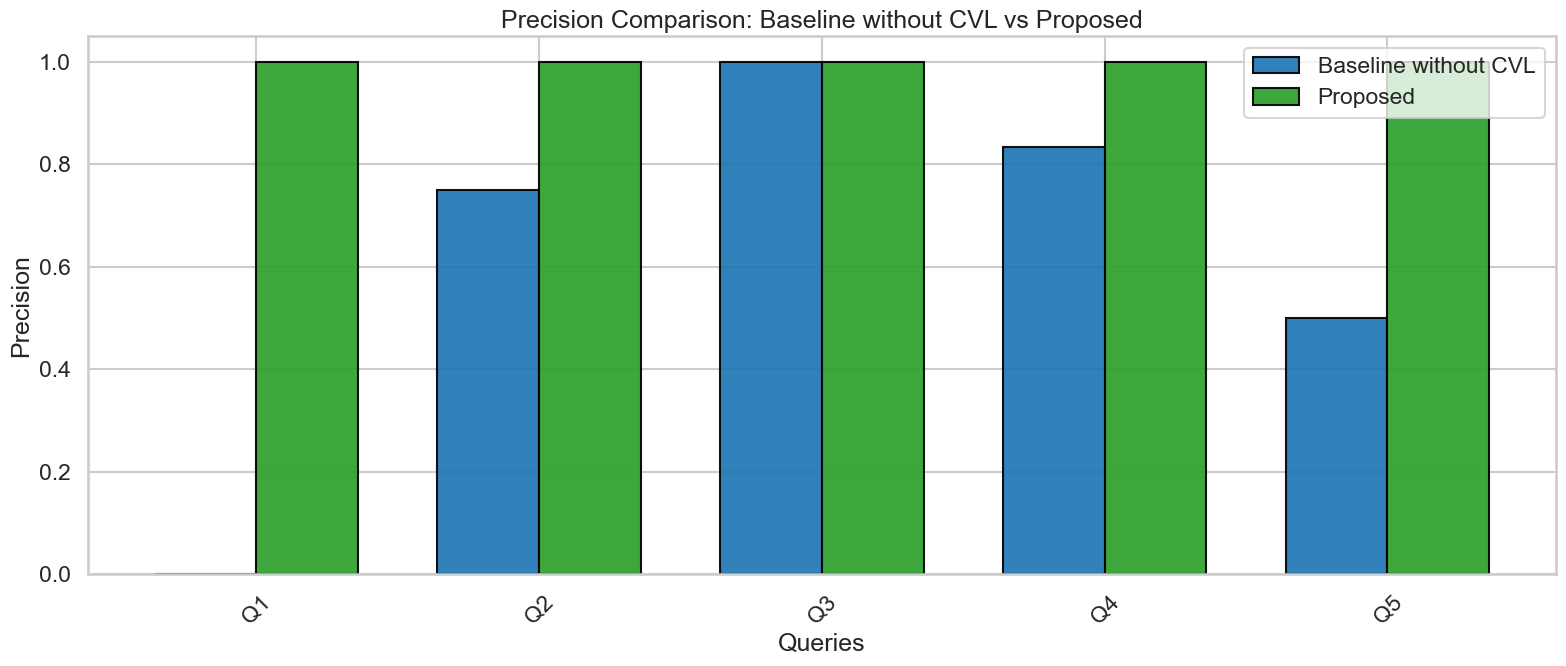

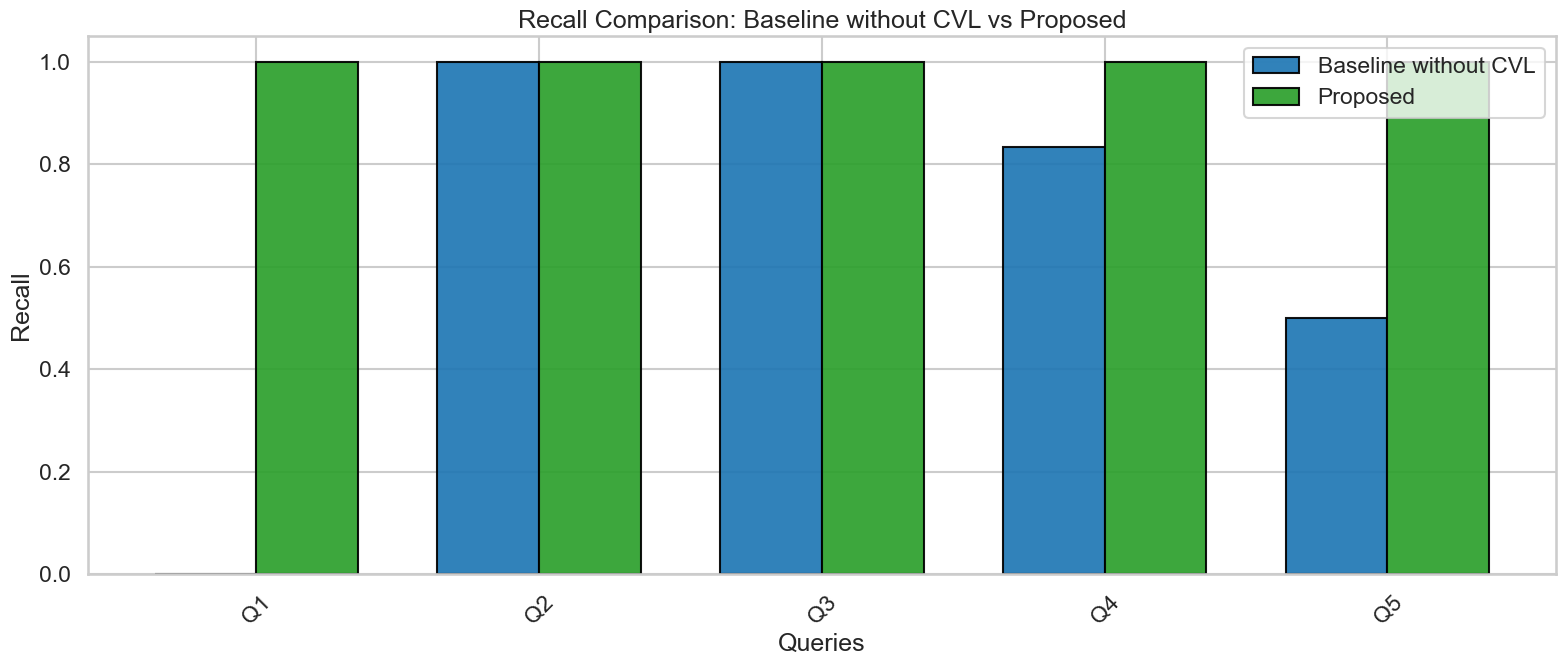

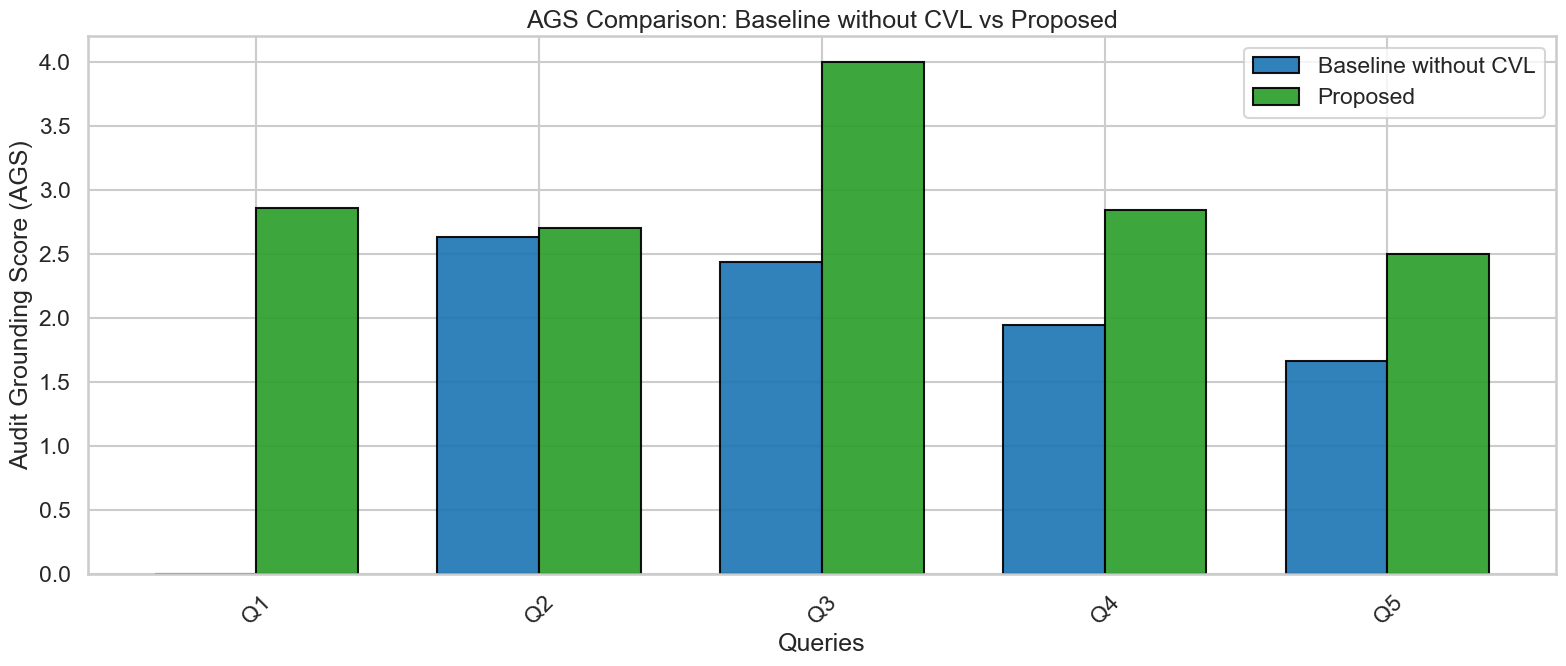

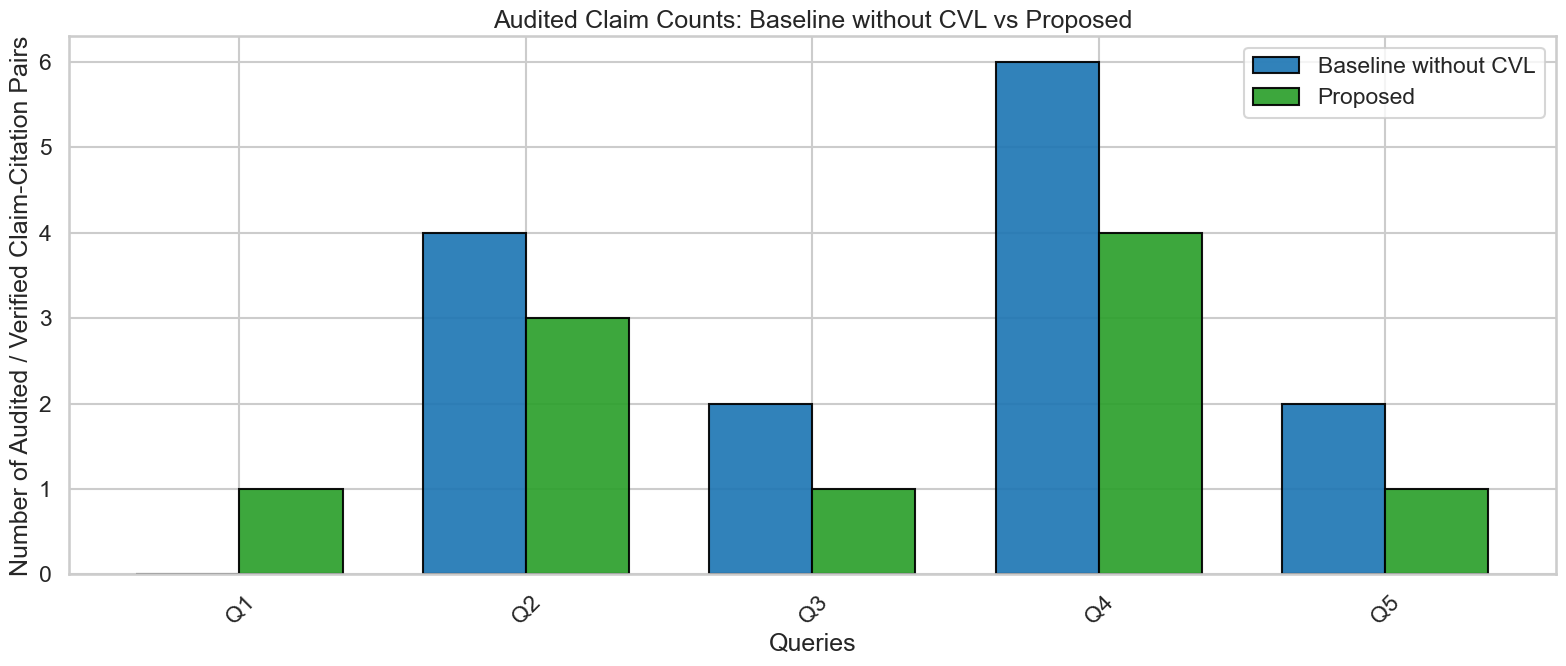

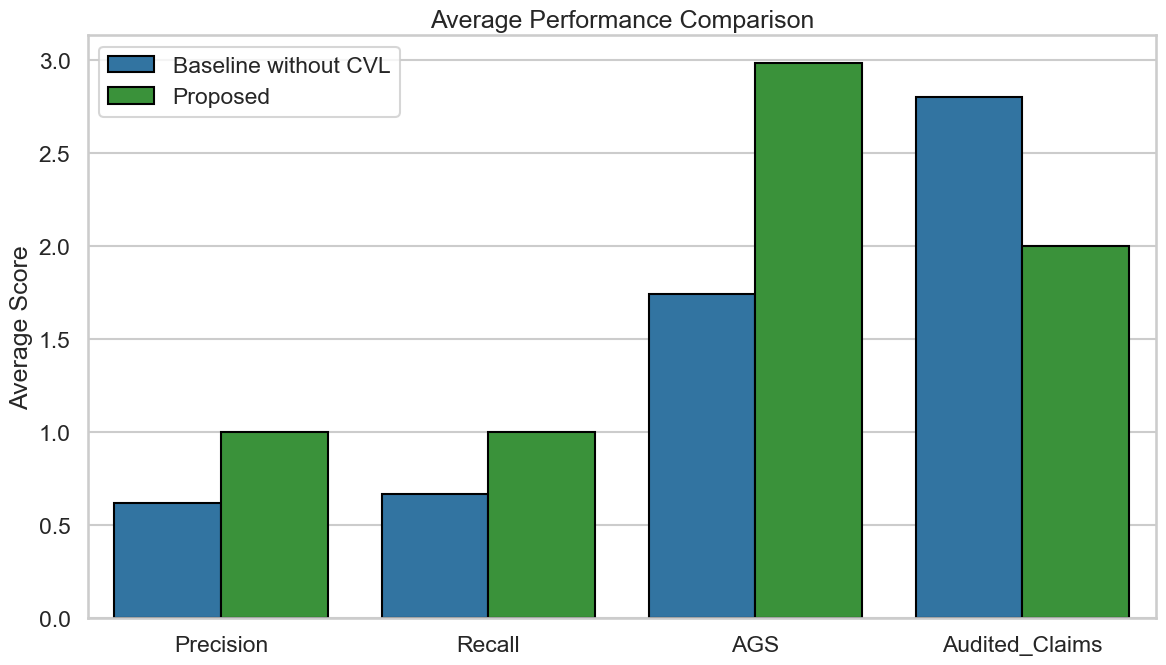

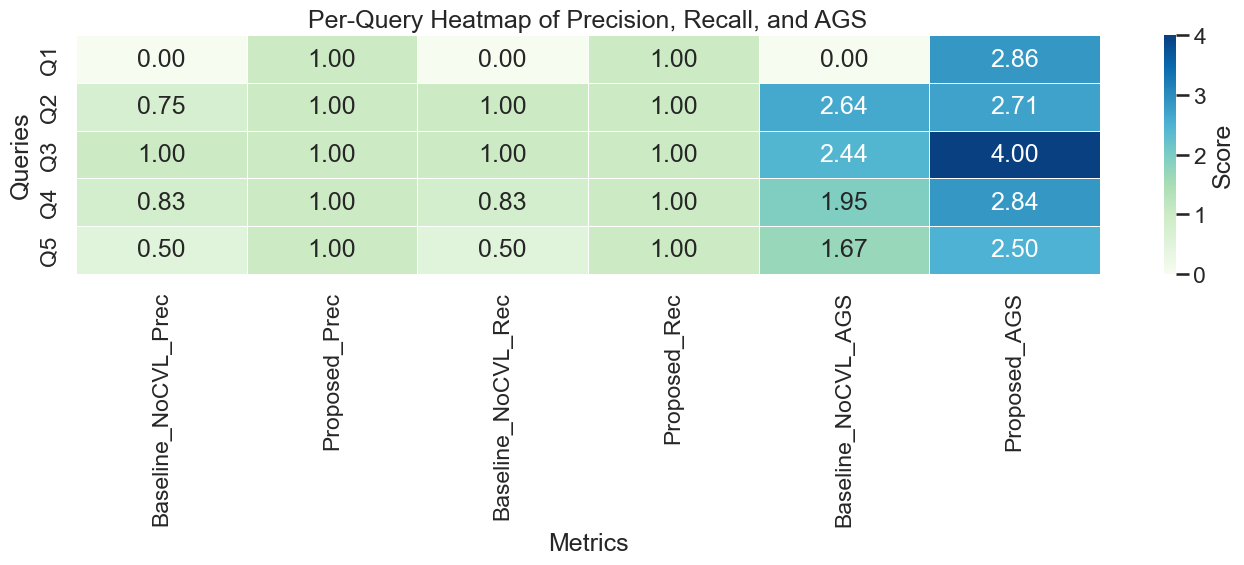

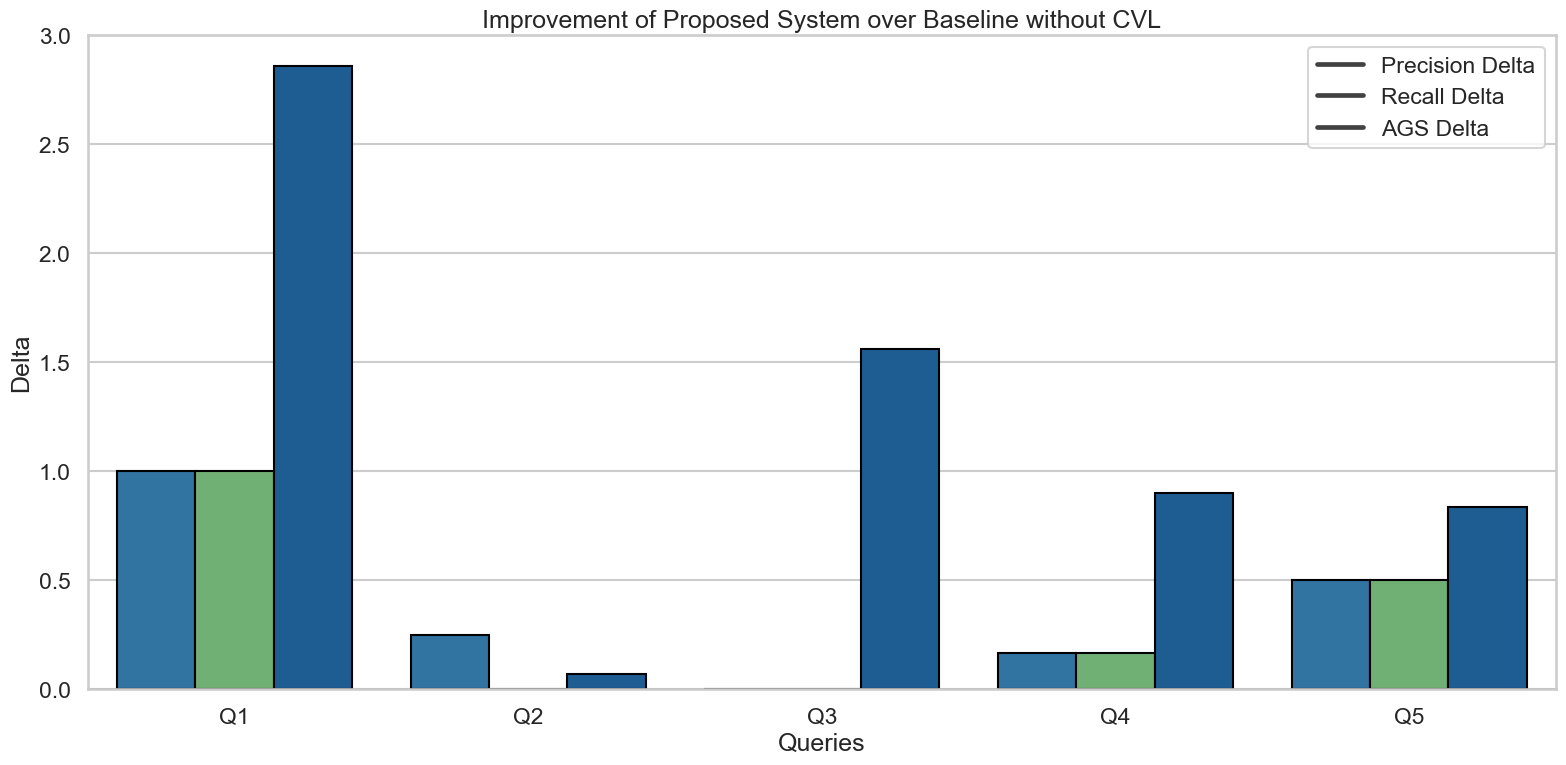

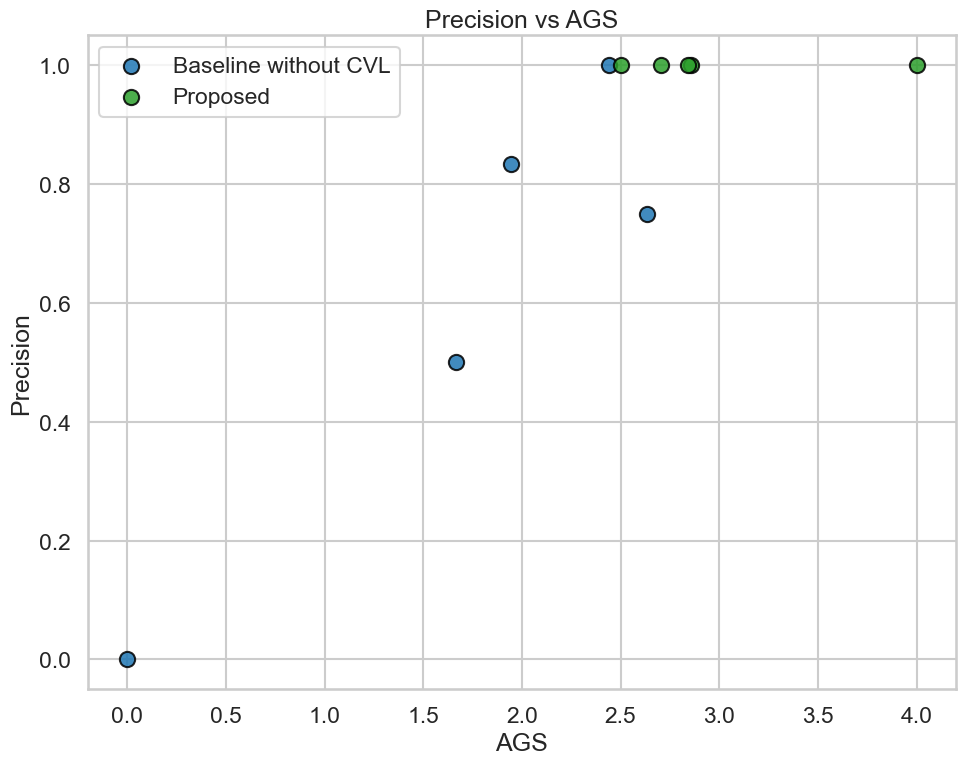

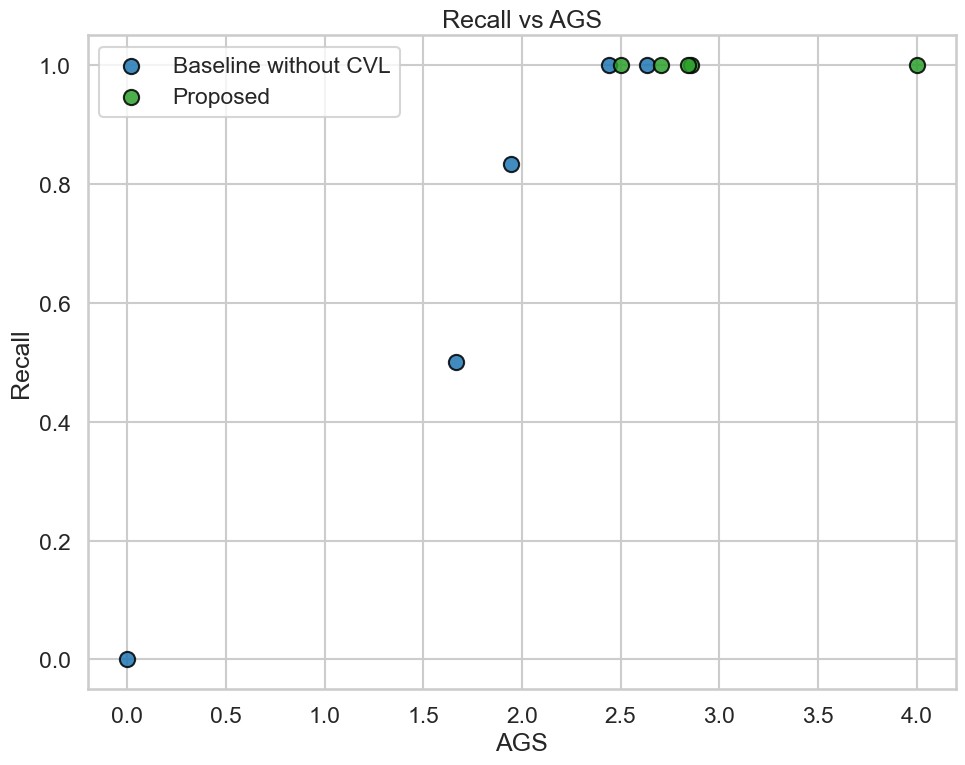

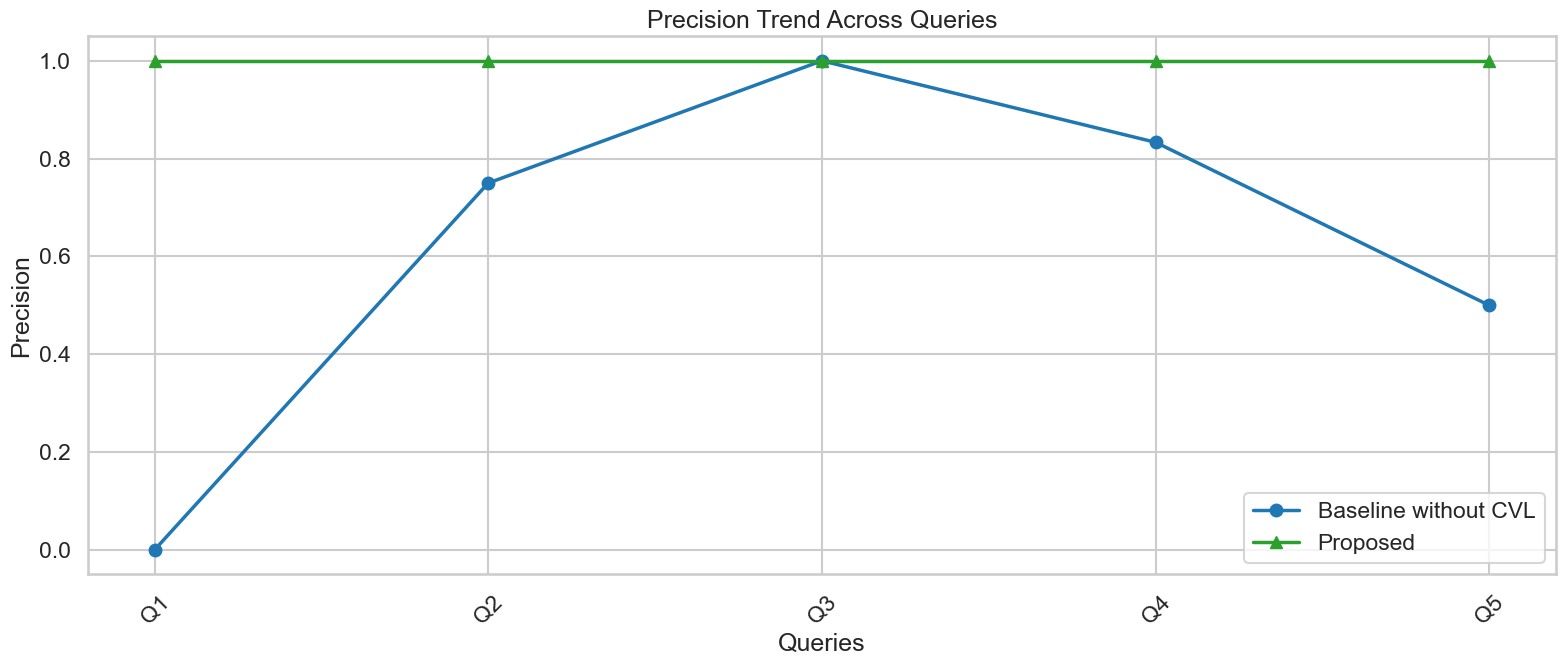

=== TWO-SYSTEM VISUALISATION SUMMARY ===
Average Baseline Precision: 0.617
Average Proposed Precision: 1.000

Average Baseline Recall:    0.667
Average Proposed Recall:    1.000

Average Baseline AGS:       1.737
Average Proposed AGS:       2.982

Queries where Proposed > Baseline on Precision: 4 / 5
Queries where Proposed > Baseline on Recall: 3 / 5
Queries where Proposed > Baseline on AGS: 5 / 5


In [93]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 0. Setup
# =========================================================
sns.set_theme(style="whitegrid", context="talk")

# Blue + green palette
COLORS = {
    "baseline_no_cvl": "#1f77b4",   # blue
    "proposed": "#2ca02c",          # green
    "delta_prec": "#1f77b4",        # blue
    "delta_rec": "#66bb6a",         # light green
    "delta_ags": "#0b5fa5",         # deep blue
    "pass": "#2ca02c",              # green
    "fail": "#98df8a",              # soft green
    "heatmap": "GnBu"
}

os.makedirs(results_dir, exist_ok=True)

plot_df = results_df.copy().reset_index(drop=True)
plot_df["Query_Label"] = [f"Q{i+1}" for i in range(len(plot_df))]

# Delta columns
plot_df["Delta_Prec_Proposed_vs_BaselineNoCVL"] = (
    plot_df["Proposed_Prec"] - plot_df["Baseline_NoCVL_Prec"]
)
plot_df["Delta_Rec_Proposed_vs_BaselineNoCVL"] = (
    plot_df["Proposed_Rec"] - plot_df["Baseline_NoCVL_Rec"]
)
plot_df["Delta_AGS_Proposed_vs_BaselineNoCVL"] = (
    plot_df["Proposed_AGS"] - plot_df["Baseline_NoCVL_AGS"]
)

# Pass/fail availability
has_pass_fail = all(col in plot_df.columns for col in [
    "Baseline_NoCVL_Num_Pass", "Baseline_NoCVL_Num_Fail",
    "Proposed_Num_Pass", "Proposed_Num_Fail"
])

def save_show_plot(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

x = np.arange(len(plot_df))
width = 0.36

# =========================================================
# 1. Precision comparison by query
# =========================================================
plt.figure(figsize=(16, 7))
plt.bar(
    x - width/2, plot_df["Baseline_NoCVL_Prec"], width=width,
    label="Baseline without CVL", color=COLORS["baseline_no_cvl"],
    edgecolor="black", alpha=0.92
)
plt.bar(
    x + width/2, plot_df["Proposed_Prec"], width=width,
    label="Proposed", color=COLORS["proposed"],
    edgecolor="black", alpha=0.92
)
plt.xticks(x, plot_df["Query_Label"], rotation=45)
plt.xlabel("Queries")
plt.ylabel("Precision")
plt.title("Precision Comparison: Baseline without CVL vs Proposed")
plt.legend()
save_show_plot("01_precision_comparison.png")

# =========================================================
# 2. Recall comparison by query
# =========================================================
plt.figure(figsize=(16, 7))
plt.bar(
    x - width/2, plot_df["Baseline_NoCVL_Rec"], width=width,
    label="Baseline without CVL", color=COLORS["baseline_no_cvl"],
    edgecolor="black", alpha=0.92
)
plt.bar(
    x + width/2, plot_df["Proposed_Rec"], width=width,
    label="Proposed", color=COLORS["proposed"],
    edgecolor="black", alpha=0.92
)
plt.xticks(x, plot_df["Query_Label"], rotation=45)
plt.xlabel("Queries")
plt.ylabel("Recall")
plt.title("Recall Comparison: Baseline without CVL vs Proposed")
plt.legend()
save_show_plot("02_recall_comparison.png")

# =========================================================
# 3. AGS comparison by query
# =========================================================
plt.figure(figsize=(16, 7))
plt.bar(
    x - width/2, plot_df["Baseline_NoCVL_AGS"], width=width,
    label="Baseline without CVL", color=COLORS["baseline_no_cvl"],
    edgecolor="black", alpha=0.92
)
plt.bar(
    x + width/2, plot_df["Proposed_AGS"], width=width,
    label="Proposed", color=COLORS["proposed"],
    edgecolor="black", alpha=0.92
)
plt.xticks(x, plot_df["Query_Label"], rotation=45)
plt.xlabel("Queries")
plt.ylabel("Audit Grounding Score (AGS)")
plt.title("AGS Comparison: Baseline without CVL vs Proposed")
plt.legend()
save_show_plot("03_ags_comparison.png")

# =========================================================
# 4. Audited / verified claim counts
# =========================================================
plt.figure(figsize=(16, 7))
plt.bar(
    x - width/2, plot_df["Baseline_NoCVL_Num_Verified_Claims"], width=width,
    label="Baseline without CVL", color=COLORS["baseline_no_cvl"],
    edgecolor="black", alpha=0.92
)
plt.bar(
    x + width/2, plot_df["Proposed_Num_Verified_Claims"], width=width,
    label="Proposed", color=COLORS["proposed"],
    edgecolor="black", alpha=0.92
)
plt.xticks(x, plot_df["Query_Label"], rotation=45)
plt.xlabel("Queries")
plt.ylabel("Number of Audited / Verified Claim-Citation Pairs")
plt.title("Audited Claim Counts: Baseline without CVL vs Proposed")
plt.legend()
save_show_plot("04_verified_claim_counts.png")

# =========================================================
# 5. Average metrics comparison
# =========================================================
avg_metrics = pd.DataFrame({
    "System": ["Baseline without CVL", "Proposed"],
    "Precision": [
        plot_df["Baseline_NoCVL_Prec"].mean(),
        plot_df["Proposed_Prec"].mean()
    ],
    "Recall": [
        plot_df["Baseline_NoCVL_Rec"].mean(),
        plot_df["Proposed_Rec"].mean()
    ],
    "AGS": [
        plot_df["Baseline_NoCVL_AGS"].mean(),
        plot_df["Proposed_AGS"].mean()
    ],
    "Audited_Claims": [
        plot_df["Baseline_NoCVL_Num_Verified_Claims"].mean(),
        plot_df["Proposed_Num_Verified_Claims"].mean()
    ]
})

avg_long = avg_metrics.melt(id_vars="System", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
sns.barplot(
    data=avg_long,
    x="Metric",
    y="Score",
    hue="System",
    palette=[COLORS["baseline_no_cvl"], COLORS["proposed"]],
    edgecolor="black"
)
plt.title("Average Performance Comparison")
plt.ylabel("Average Score")
plt.xlabel("")
plt.legend(title="")
save_show_plot("05_average_metric_comparison.png")

# =========================================================
# 6. Heatmap overview
# =========================================================
heatmap_cols = [
    "Baseline_NoCVL_Prec", "Proposed_Prec",
    "Baseline_NoCVL_Rec", "Proposed_Rec",
    "Baseline_NoCVL_AGS", "Proposed_AGS"
]

heatmap_df = plot_df.set_index("Query_Label")[heatmap_cols]

plt.figure(figsize=(14, max(6, len(plot_df) * 0.5)))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap=COLORS["heatmap"],
    linewidths=0.5,
    cbar_kws={"label": "Score"}
)
plt.title("Per-Query Heatmap of Precision, Recall, and AGS")
plt.xlabel("Metrics")
plt.ylabel("Queries")
save_show_plot("06_two_system_metrics_heatmap.png")

# =========================================================
# 7. Delta: Proposed vs Baseline without CVL
# =========================================================
delta_prop_vs_b0 = plot_df[[
    "Query_Label",
    "Delta_Prec_Proposed_vs_BaselineNoCVL",
    "Delta_Rec_Proposed_vs_BaselineNoCVL",
    "Delta_AGS_Proposed_vs_BaselineNoCVL"
]].melt(id_vars="Query_Label", var_name="Metric", value_name="Delta")

metric_palette = {
    "Delta_Prec_Proposed_vs_BaselineNoCVL": COLORS["delta_prec"],
    "Delta_Rec_Proposed_vs_BaselineNoCVL": COLORS["delta_rec"],
    "Delta_AGS_Proposed_vs_BaselineNoCVL": COLORS["delta_ags"]
}

plt.figure(figsize=(16, 8))
sns.barplot(
    data=delta_prop_vs_b0,
    x="Query_Label",
    y="Delta",
    hue="Metric",
    palette=metric_palette,
    edgecolor="black"
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Improvement of Proposed System over Baseline without CVL")
plt.xlabel("Queries")
plt.ylabel("Delta")
plt.legend(
    title="",
    labels=["Precision Delta", "Recall Delta", "AGS Delta"]
)
save_show_plot("07_delta_proposed_vs_baseline.png")

# =========================================================
# 8. Scatter plot: Precision vs AGS
# =========================================================
plt.figure(figsize=(10, 8))
plt.scatter(
    plot_df["Baseline_NoCVL_AGS"], plot_df["Baseline_NoCVL_Prec"],
    s=120, color=COLORS["baseline_no_cvl"], label="Baseline without CVL",
    alpha=0.85, edgecolors="black"
)
plt.scatter(
    plot_df["Proposed_AGS"], plot_df["Proposed_Prec"],
    s=120, color=COLORS["proposed"], label="Proposed",
    alpha=0.85, edgecolors="black"
)
plt.xlabel("AGS")
plt.ylabel("Precision")
plt.title("Precision vs AGS")
plt.legend()
save_show_plot("08_precision_vs_ags_scatter.png")

# =========================================================
# 9. Scatter plot: Recall vs AGS
# =========================================================
plt.figure(figsize=(10, 8))
plt.scatter(
    plot_df["Baseline_NoCVL_AGS"], plot_df["Baseline_NoCVL_Rec"],
    s=120, color=COLORS["baseline_no_cvl"], label="Baseline without CVL",
    alpha=0.85, edgecolors="black"
)
plt.scatter(
    plot_df["Proposed_AGS"], plot_df["Proposed_Rec"],
    s=120, color=COLORS["proposed"], label="Proposed",
    alpha=0.85, edgecolors="black"
)
plt.xlabel("AGS")
plt.ylabel("Recall")
plt.title("Recall vs AGS")
plt.legend()
save_show_plot("09_recall_vs_ags_scatter.png")

# =========================================================
# 10. Pass/fail stacked bars
# =========================================================
if has_pass_fail:
    fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

    # Baseline without CVL
    axes[0].bar(
        plot_df["Query_Label"], plot_df["Baseline_NoCVL_Num_Pass"],
        color=COLORS["pass"], edgecolor="black", label="Pass"
    )
    axes[0].bar(
        plot_df["Query_Label"], plot_df["Baseline_NoCVL_Num_Fail"],
        bottom=plot_df["Baseline_NoCVL_Num_Pass"],
        color=COLORS["fail"], edgecolor="black", label="Fail"
    )
    axes[0].set_title("Baseline without CVL")
    axes[0].set_xlabel("Queries")
    axes[0].set_ylabel("Audited Claim-Citation Pairs")
    axes[0].tick_params(axis="x", rotation=45)

    # Proposed
    axes[1].bar(
        plot_df["Query_Label"], plot_df["Proposed_Num_Pass"],
        color=COLORS["pass"], edgecolor="black", label="Pass"
    )
    axes[1].bar(
        plot_df["Query_Label"], plot_df["Proposed_Num_Fail"],
        bottom=plot_df["Proposed_Num_Pass"],
        color=COLORS["fail"], edgecolor="black", label="Fail"
    )
    axes[1].set_title("Proposed")
    axes[1].set_xlabel("Queries")
    axes[1].tick_params(axis="x", rotation=45)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    plt.suptitle("Pass/Fail Distribution", y=1.03)
    plt.tight_layout()
    plt.savefig(
        os.path.join(results_dir, "10_pass_fail_stacked_bars.png"),
        dpi=300, bbox_inches="tight"
    )
    plt.show()
    plt.close()

# =========================================================
# 11. Average pass/fail comparison
# =========================================================
if has_pass_fail:
    avg_pf = pd.DataFrame({
        "System": ["Baseline without CVL", "Proposed"],
        "Pass": [
            plot_df["Baseline_NoCVL_Num_Pass"].mean(),
            plot_df["Proposed_Num_Pass"].mean()
        ],
        "Fail": [
            plot_df["Baseline_NoCVL_Num_Fail"].mean(),
            plot_df["Proposed_Num_Fail"].mean()
        ]
    })

    avg_pf_long = avg_pf.melt(
        id_vars="System", var_name="Outcome", value_name="Average_Count"
    )

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=avg_pf_long,
        x="System",
        y="Average_Count",
        hue="Outcome",
        palette={"Pass": COLORS["pass"], "Fail": COLORS["fail"]},
        edgecolor="black"
    )
    plt.title("Average Pass/Fail Counts")
    plt.xlabel("")
    plt.ylabel("Average Count")
    plt.legend(title="")
    save_show_plot("11_average_pass_fail_comparison.png")

# =========================================================
# 12. Line plot: precision trends across queries
# =========================================================
plt.figure(figsize=(16, 7))
plt.plot(
    plot_df["Query_Label"], plot_df["Baseline_NoCVL_Prec"],
    marker="o", linewidth=2.5, label="Baseline without CVL",
    color=COLORS["baseline_no_cvl"]
)
plt.plot(
    plot_df["Query_Label"], plot_df["Proposed_Prec"],
    marker="^", linewidth=2.5, label="Proposed",
    color=COLORS["proposed"]
)
plt.xticks(rotation=45)
plt.xlabel("Queries")
plt.ylabel("Precision")
plt.title("Precision Trend Across Queries")
plt.legend()
save_show_plot("12_precision_trend_lines.png")

# =========================================================
# 13. Summary printout
# =========================================================
print("=== TWO-SYSTEM VISUALISATION SUMMARY ===")
print(f"Average Baseline Precision: {plot_df['Baseline_NoCVL_Prec'].mean():.3f}")
print(f"Average Proposed Precision: {plot_df['Proposed_Prec'].mean():.3f}")
print()
print(f"Average Baseline Recall:    {plot_df['Baseline_NoCVL_Rec'].mean():.3f}")
print(f"Average Proposed Recall:    {plot_df['Proposed_Rec'].mean():.3f}")
print()
print(f"Average Baseline AGS:       {plot_df['Baseline_NoCVL_AGS'].mean():.3f}")
print(f"Average Proposed AGS:       {plot_df['Proposed_AGS'].mean():.3f}")
print()
print(
    "Queries where Proposed > Baseline on Precision: "
    f"{(plot_df['Delta_Prec_Proposed_vs_BaselineNoCVL'] > 0).sum()} / {len(plot_df)}"
)
print(
    "Queries where Proposed > Baseline on Recall: "
    f"{(plot_df['Delta_Rec_Proposed_vs_BaselineNoCVL'] > 0).sum()} / {len(plot_df)}"
)
print(
    "Queries where Proposed > Baseline on AGS: "
    f"{(plot_df['Delta_AGS_Proposed_vs_BaselineNoCVL'] > 0).sum()} / {len(plot_df)}"
)

#### Summary

In [ ]:
print("\n=== SUMMARY ===")
print("Avg Baseline Precision:", results_df["Baseline_NoCVL_Prec"].mean())
print("Avg Proposed Precision:", results_df["Proposed_Prec"].mean())
print("Avg Baseline Recall:", results_df["Baseline_Rec"].mean())
print("Avg Proposed Recall:", results_df["Proposed_Rec"].mean())
print("Avg Baseline AGS:", results_df["Baseline_NoCVL_AGS"].mean())
print("Avg Proposed AGS:", results_df["Proposed_AGS"].mean())
print("Queries with Baseline audited:", len(results_df))
print("Baseline precision is now measured query by query from audited citations, not fixed.")




=== SUMMARY ===
Avg Baseline Precision: 0.55
Avg Proposed Precision: 0.0
Avg Baseline AGS: 0.5846629273135711
Avg Proposed AGS: 0.0
